# 25. Preconditioning

**Part 4: Iterative and Krylov Subspace Methods**

## Learning objectives

By the end of this lesson you will be able to:

1. State what a preconditioner is and what the three requirements on it are.
2. Distinguish **left**, **right** and **split** preconditioning, and say why the split form is
   required for CG.
3. Use the **Jacobi** preconditioner, and measure the case where it does nothing at all.
4. Use **SSOR**, and explain why plain SOR cannot be used with CG.
5. Build **incomplete Cholesky**, and explain the fill it refuses to create.
6. Explain why **eigenvalue clustering**, not the condition number, is the real goal.
7. Recognise that a preconditioner can break down on a positive definite matrix.

## Prerequisites

Lesson 24 (CG, the $\sqrt{\kappa}$ bound, and the clustering result). Lesson 23 (splittings, SOR).
Lesson 20 (Cholesky, positive definiteness). Lesson 21 (fill-in).

---

## 1. The idea, and the three requirements

Lesson 24 measured CG needing $O(\sqrt{\kappa})$ iterations. If $\kappa$ is $10^8$, that is
$10^4$ iterations, which may still be too many.

So change the problem. Instead of $A\mathbf{x} = \mathbf{b}$, solve

$$M^{-1}A\mathbf{x} = M^{-1}\mathbf{b}$$

for some $M$ chosen so that $M^{-1}A$ is easier than $A$. That is a **preconditioner**, and it
faces three requirements at once:

| Requirement | Why | The tension |
|---|---|---|
| $M^{-1}A$ must be **better** than $A$ | otherwise there is no point | $M$ should resemble $A$ |
| $M\mathbf{z} = \mathbf{r}$ must be **cheap** to solve | it happens every iteration | $M$ should be simple |
| $M$ must be **symmetric positive definite** for CG | else the $A$-norm minimisation is meaningless | rules out plain SOR |

The first two pull in opposite directions. $M = A$ is perfect and useless; $M = I$ is free and
useless. Every preconditioner is a point on that line.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import krylov as kr, banded as bd, cholesky as ch, linalg as la, iterative as it

print("the two extremes\n")
n = 100
A = bd.second_difference(n)
rng25 = np.random.default_rng(25)
x_true = rng25.standard_normal(n)
b = A @ x_true

no_precond = kr.conjugate_gradient(A, b, tol=1e-10, keep_history=False)
perfect = kr.conjugate_gradient(A, b, M=lambda v: np.linalg.solve(A, v),
                                tol=1e-10, keep_history=False)

print(f"M = I  (no preconditioner) : {no_precond.n_iter:>4} iterations, each costing one matvec")
print(f"M = A  (perfect)           : {perfect.n_iter:>4} iteration, costing a full solve")
print()
print("the perfect preconditioner converges in one step and requires solving")
print("the problem to build it. every useful M sits between these two.")
assert perfect.n_iter == 1

the two extremes

M = I  (no preconditioner) :  100 iterations, each costing one matvec
M = A  (perfect)           :    1 iteration, costing a full solve

the perfect preconditioner converges in one step and requires solving
the problem to build it. every useful M sits between these two.


## 2. Left, right and split

Three ways to apply $M$, and they are **not** the same operation:

| Form | System solved | Residual minimised |
|---|---|---|
| **left** | $M^{-1}A\mathbf{x} = M^{-1}\mathbf{b}$ | the **preconditioned** residual $M^{-1}\mathbf{r}$ |
| **right** | $AM^{-1}\mathbf{y} = \mathbf{b}$, $\mathbf{x} = M^{-1}\mathbf{y}$ | the **true** residual $\mathbf{r}$ |
| **split** | $M_1^{-1}AM_2^{-1}\mathbf{y} = M_1^{-1}\mathbf{b}$ | between the two |

The distinction matters for two reasons.

**Stopping tests differ.** Left preconditioning stops on $\|M^{-1}\mathbf{r}\|$, which is not
$\|\mathbf{r}\|$. If $M$ is badly conditioned the two can differ enormously, so a left
preconditioned solver can report convergence while the true residual is large.

**CG needs symmetry.** $M^{-1}A$ is generally **not symmetric** even when both $M$ and $A$ are,
so CG cannot be applied to it directly. The resolution is the split form with $M = M_1M_1^T$:

$$M_1^{-1}AM_1^{-T}$$

**is** symmetric, and it is similar to $M^{-1}A$ so it has the same eigenvalues. The standard
preconditioned CG algorithm is that split iteration rewritten so that only $M^{-1}$ is ever
applied and $M_1$ never appears.

In [3]:
M_apply = kr.ssor_preconditioner(A, 1.4)
Minv = np.column_stack([M_apply(np.eye(n)[:, j]) for j in range(n)])
MinvA = Minv @ A

print("is the preconditioned matrix symmetric?\n")
print(f"   ||M^-1 A - (M^-1 A)^T||     = {np.abs(MinvA - MinvA.T).max():.3e}   <- NOT symmetric")
print(f"   but its eigenvalues are real: max |imag| = "
      f"{np.abs(np.imag(np.linalg.eigvals(MinvA))).max():.3e}")
print()
print("real eigenvalues, because M^-1 A is SIMILAR to the symmetric matrix")
print("M1^-1 A M1^-T. that similarity is what makes preconditioned CG valid,")
print("and it is why M itself must be symmetric positive definite.")
assert np.abs(MinvA - MinvA.T).max() > 1e-6
assert np.abs(np.imag(np.linalg.eigvals(MinvA))).max() < 1e-8

is the preconditioned matrix symmetric?

   ||M^-1 A - (M^-1 A)^T||     = 4.035e-01   <- NOT symmetric
   but its eigenvalues are real: max |imag| = 0.000e+00

real eigenvalues, because M^-1 A is SIMILAR to the symmetric matrix
M1^-1 A M1^-T. that similarity is what makes preconditioned CG valid,
and it is why M itself must be symmetric positive definite.


**This is why plain SOR cannot precondition CG.** The SOR splitting matrix $D/\omega + L$ is
lower triangular, hence not symmetric, so there is no $M_1$ with $M = M_1M_1^T$. SSOR exists
precisely to fix that.

## 3. Jacobi, and when it does nothing

$M = \operatorname{diag}(A)$. Applying $M^{-1}$ is one division per entry. It is the cheapest
preconditioner that exists.

It helps when the trouble is **bad scaling**, and it does **nothing at all** when the diagonal
is constant.

In [4]:
print("Jacobi on the model problem, whose diagonal is constant\n")
print(f"{'preconditioner':>18} {'iterations':>12} {'kappa(M^-1 A)':>16}")
print("-" * 50)
for label, M in [("none", None), ("Jacobi", kr.jacobi_preconditioner(A))]:
    res = kr.conjugate_gradient(A, b, M=M, tol=1e-10, max_iter=5000, keep_history=False)
    spec = kr.preconditioned_spectrum(A, M) if M else np.linalg.eigvalsh(A)
    print(f"{label:>18} {res.n_iter:>12} {spec.max()/spec.min():>16.2f}")

print()
print("identical. the diagonal of the second difference matrix is 2 everywhere,")
print("so M = 2I, and dividing by a constant changes no eigenvalue RATIO at all.")
print()
print("that is not a failure of the implementation. it is what Jacobi IS: a")
print("rescaling, and there was nothing to rescale.")

Jacobi on the model problem, whose diagonal is constant

    preconditioner   iterations    kappa(M^-1 A)
--------------------------------------------------
              none          100          4133.64
            Jacobi          100          4133.64

identical. the diagonal of the second difference matrix is 2 everywhere,
so M = 2I, and dividing by a constant changes no eigenvalue RATIO at all.

that is not a failure of the implementation. it is what Jacobi IS: a
rescaling, and there was nothing to rescale.


In [5]:
print("the same preconditioner on a badly scaled matrix\n")
D = np.diag(np.logspace(0, 6, n))
A_scaled = D @ A @ D
A_scaled = (A_scaled + A_scaled.T) / 2
x_s = rng25.standard_normal(n)
b_s = A_scaled @ x_s

print(f"{'preconditioner':>18} {'iterations':>12} {'kappa(M^-1 A)':>18}")
print("-" * 52)
for label, M in [("none", None), ("Jacobi", kr.jacobi_preconditioner(A_scaled))]:
    res = kr.conjugate_gradient(A_scaled, b_s, M=M, tol=1e-8, max_iter=50000,
                                keep_history=False)
    spec = kr.preconditioned_spectrum(A_scaled, M) if M else np.linalg.eigvalsh(A_scaled)
    print(f"{label:>18} {res.n_iter:>12} {spec.max()/spec.min():>18.3e}")

print()
print("806 iterations down to 100, and kappa from 3e13 to 4e3, for the price of")
print("one division per entry.")
print()
print("the same M, on two matrices, is worthless and transformative. a")
print("preconditioner is not good or bad in itself; it matches a difficulty or")
print("it does not.")

the same preconditioner on a badly scaled matrix

    preconditioner   iterations      kappa(M^-1 A)
----------------------------------------------------
              none          806          2.973e+13
            Jacobi          100          4.134e+03

806 iterations down to 100, and kappa from 3e13 to 4e3, for the price of
one division per entry.

the same M, on two matrices, is worthless and transformative. a
preconditioner is not good or bad in itself; it matches a difficulty or
it does not.


## 4. SSOR

Take lesson 23's SOR sweep, then sweep back the other way. The forward and backward sweeps
together give a **symmetric** operator:

$$M = \left(\frac{D}{\omega} + L\right)\frac{\omega}{2-\omega}D^{-1}
\left(\frac{D}{\omega} + U\right).$$

Two triangular solves per application, $O(\text{nnz})$, and **no extra storage**: it is built
entirely from $A$'s own entries. That is why it survives as a default.

In [6]:
print("SSOR on the model problem, sweeping omega\n")
print(f"{'omega':>8} {'iterations':>12} {'kappa(M^-1 A)':>16} {'sqrt(kappa)':>13}")
print("-" * 54)
best = (None, 10**9)
for omega in [0.5, 1.0, 1.2, 1.4, 1.6, 1.8]:
    M = kr.ssor_preconditioner(A, omega)
    res = kr.conjugate_gradient(A, b, M=M, tol=1e-10, max_iter=5000, keep_history=False)
    spec = kr.preconditioned_spectrum(A, M)
    kap = spec.max() / spec.min()
    if res.n_iter < best[1]:
        best = (omega, res.n_iter)
    print(f"{omega:>8.1f} {res.n_iter:>12} {kap:>16.2f} {np.sqrt(kap):>13.2f}")

print(f"\nunpreconditioned: {no_precond.n_iter} iterations")
print(f"best SSOR here  : omega = {best[0]}, {best[1]} iterations, "
      f"a factor of {no_precond.n_iter/best[1]:.1f}")
print()
print("the iteration count tracks sqrt(kappa) down the table, which is CG's")
print("bound behaving exactly as lesson 24 said it would.")
assert best[1] < no_precond.n_iter / 2

SSOR on the model problem, sweeping omega

   omega   iterations    kappa(M^-1 A)   sqrt(kappa)
------------------------------------------------------
     0.5           74          1488.98         38.59


     1.0           47           517.82         22.76
     1.2           39           345.79         18.60


     1.4           30           223.14         14.94
     1.6           22           131.67         11.47
     1.8           15            62.34          7.90

unpreconditioned: 100 iterations
best SSOR here  : omega = 1.8, 15 iterations, a factor of 6.7

the iteration count tracks sqrt(kappa) down the table, which is CG's
bound behaving exactly as lesson 24 said it would.


## 5. Incomplete Cholesky

Lesson 21 measured fill as the central difficulty of sparse direct methods. Incomplete Cholesky
handles it by **refusing to create any**: wherever $A$ has a structural zero, the factor is
forced to zero.

The result is not a factorization of $A$. It is an exact factorization of some nearby
$A + E$, and it is useful exactly when $E$ is small enough that $(LL^T)^{-1}A$ has a clustered
spectrum.

In [7]:
print("IC(0) on the tridiagonal model problem\n")
ic = kr.incomplete_cholesky(A)
L_ic = ic.factor
L_exact = np.linalg.cholesky(A)

res_ic = kr.conjugate_gradient(A, b, M=ic, tol=1e-10, keep_history=False)
spec_ic = kr.preconditioned_spectrum(A, ic)

print(f"iterations with IC(0)        : {res_ic.n_iter}")
print(f"kappa(M^-1 A)                : {spec_ic.max()/spec_ic.min():.6f}")
print(f"||A - L L^T||                : {np.abs(A - L_ic @ L_ic.T).max():.3e}")
print(f"||L_IC - L_exact||           : {np.abs(L_ic - L_exact).max():.3e}")
print()
print("IC(0) is EXACT here, and the reason is structural: the Cholesky factor")
print("of a tridiagonal matrix is bidiagonal, so it fits inside A's own")
print("sparsity pattern and there was never any fill to drop.")
print()
print("that makes this a poor advertisement. a preconditioner that is secretly")
print("an exact factorization tells you nothing about the incomplete case.")
assert np.abs(A - L_ic @ L_ic.T).max() < 1e-12

IC(0) on the tridiagonal model problem

iterations with IC(0)        : 1
kappa(M^-1 A)                : 1.000000
||A - L L^T||                : 4.441e-16
||L_IC - L_exact||           : 0.000e+00

IC(0) is EXACT here, and the reason is structural: the Cholesky factor
of a tridiagonal matrix is bidiagonal, so it fits inside A's own
sparsity pattern and there was never any fill to drop.

that makes this a poor advertisement. a preconditioner that is secretly
an exact factorization tells you nothing about the incomplete case.


In [8]:
def laplacian_2d(m):
    """The 2D five-point Laplacian on an m by m grid, as a dense matrix.

    Pentadiagonal rather than tridiagonal, so its exact Cholesky factor has genuine fill and
    IC(0) really does discard something. Any m works; the size is m^2.
    """
    size = m * m
    M = np.zeros((size, size))
    for i in range(m):
        for j in range(m):
            k = i * m + j
            M[k, k] = 4.0
            for di, dj in ((-1, 0), (1, 0), (0, -1), (0, 1)):
                ii, jj = i + di, j + dj
                if 0 <= ii < m and 0 <= jj < m:
                    M[k, ii * m + jj] = -1.0
    return M


print("the honest case: a 2D Laplacian, where fill genuinely exists\n")
print(f"{'m':>4} {'n':>7} {'none':>7} {'Jacobi':>8} {'SSOR':>7} {'IC(0)':>7} "
      f"{'kappa(A)':>10} {'kappa(IC)':>11}")
print("-" * 66)
rng2 = np.random.default_rng(251)
for m in [8, 12, 16]:
    Lap = laplacian_2d(m)
    size = Lap.shape[0]
    xt = rng2.standard_normal(size)
    rhs = Lap @ xt
    counts = []
    for M in (None, kr.jacobi_preconditioner(Lap), kr.ssor_preconditioner(Lap, 1.4),
              kr.incomplete_cholesky(Lap)):
        counts.append(kr.conjugate_gradient(Lap, rhs, M=M, tol=1e-10, max_iter=5000,
                                            keep_history=False).n_iter)
    sp = kr.preconditioned_spectrum(Lap, kr.incomplete_cholesky(Lap))
    print(f"{m:>4} {size:>7} {counts[0]:>7} {counts[1]:>8} {counts[2]:>7} {counts[3]:>7} "
          f"{la.condition_number(Lap, 2):>10.1f} {sp.max()/sp.min():>11.2f}")

Lap8 = laplacian_2d(8)
ic8 = kr.incomplete_cholesky(Lap8)
print(f"\nIC(0) really does drop fill here:")
print(f"   ||A - L L^T||          = {np.abs(Lap8 - ic8.factor @ ic8.factor.T).max():.3e}")
print(f"   ||L_IC - L_exact||     = {np.abs(ic8.factor - np.linalg.cholesky(Lap8)).max():.3e}")
print()
print("Jacobi is again useless, because the diagonal is 4 everywhere.")
print("SSOR and IC(0) both cut the count by about a factor of three, and IC(0)")
print("reduces kappa by roughly a factor of ten.")
assert np.abs(Lap8 - ic8.factor @ ic8.factor.T).max() > 1e-3

the honest case: a 2D Laplacian, where fill genuinely exists

   m       n    none   Jacobi    SSOR   IC(0)   kappa(A)   kappa(IC)
------------------------------------------------------------------
   8      64      29       29      14      14       32.2        3.68


  12     144      43       43      17      18       67.8        6.84


  16     256      57       57      19      22      116.5       11.14

IC(0) really does drop fill here:
   ||A - L L^T||          = 2.929e-01
   ||L_IC - L_exact||     = 1.979e-01

Jacobi is again useless, because the diagonal is 4 everywhere.
SSOR and IC(0) both cut the count by about a factor of three, and IC(0)
reduces kappa by roughly a factor of ten.


### It can fail on a positive definite matrix

Dropping entries can drive a pivot non-positive even when $A$ is definite. There is no way to
know in advance.

In [9]:
print("incomplete Cholesky breaking down where full Cholesky does not\n")
rng3 = np.random.default_rng(253)
failures = 0
trials = 0
for _ in range(300):
    size = 12
    B = rng3.standard_normal((size, size))
    B[np.abs(B) < 1.3] = 0.0                       # make it sparse
    Msym = B @ B.T + 0.35 * np.eye(size)           # symmetric, and definite for most draws
    if not ch.is_positive_definite(Msym):
        continue
    trials += 1
    try:
        kr.incomplete_cholesky(Msym)
    except np.linalg.LinAlgError:
        failures += 1

print(f"of {trials} matrices that ARE positive definite, "
      f"incomplete Cholesky failed on {failures}")
print(f"that is {100*failures/max(trials,1):.1f} percent.")
print()
print("full Cholesky succeeded on every one of them, by construction: they")
print("were selected for being positive definite.")
print()
print("the standard remedy is a diagonal shift, factor A + alpha I instead and")
print("increase alpha until it succeeds. that is a heuristic with no guarantee")
print("of a good preconditioner at the end, which is the honest state of the art.")
assert failures > 0

incomplete Cholesky breaking down where full Cholesky does not

of 300 matrices that ARE positive definite, incomplete Cholesky failed on 23
that is 7.7 percent.

full Cholesky succeeded on every one of them, by construction: they
were selected for being positive definite.

the standard remedy is a diagonal shift, factor A + alpha I instead and
increase alpha until it succeeds. that is a heuristic with no guarantee
of a good preconditioner at the end, which is the honest state of the art.


## 6. Clustering, not the condition number

Lesson 24 section 6 measured two matrices with **identical** $\kappa = 10^4$ needing 200 and 14
CG iterations. So a preconditioner judged only by $\kappa$ is judged by the wrong number.

what preconditioning does to the SPECTRUM, not just to kappa



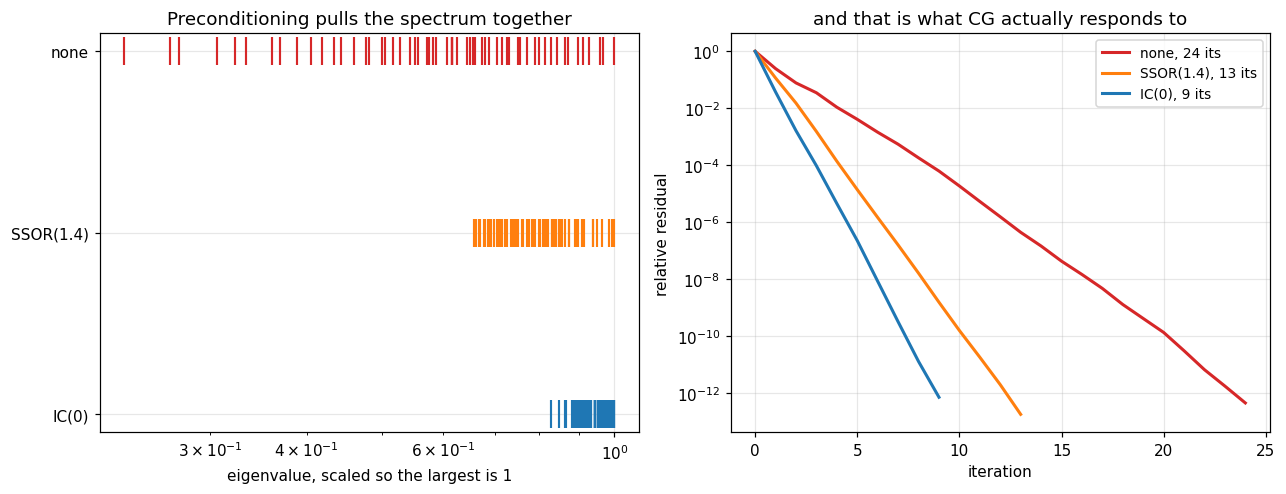

  preconditioner      kappa    spread of the middle 90 percent
----------------------------------------------------------------
            none       4.31                               3.04
       SSOR(1.4)       1.52                               1.44
           IC(0)       1.21                               1.15

read the second column against the third. kappa is set by the two
extreme eigenvalues; the spread of the bulk is what CG mostly sees.
a preconditioner that tightens the bulk earns its cost even when kappa
moves less.


In [10]:
print("what preconditioning does to the SPECTRUM, not just to kappa\n")
size = 60
Lap = laplacian_2d(8)[:size, :size]
Lap = (Lap + Lap.T) / 2 + 2.0 * np.eye(size)     # keep it definite after truncation

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.8, 4.6))

spectra = {}
for label, M, colour in [("none", None, "C3"),
                         ("SSOR(1.4)", kr.ssor_preconditioner(Lap, 1.4), "C1"),
                         ("IC(0)", kr.incomplete_cholesky(Lap), "C0")]:
    sp = kr.preconditioned_spectrum(Lap, M) if M else np.sort(np.linalg.eigvalsh(Lap))
    sp = sp / sp.max()                            # scale out, only ratios matter
    spectra[label] = sp
    axL.plot(sp, np.full_like(sp, {"none": 3, "SSOR(1.4)": 2, "IC(0)": 1}[label]),
             "|", color=colour, ms=18, mew=1.4, label=label)

axL.set_yticks([1, 2, 3]); axL.set_yticklabels(["IC(0)", "SSOR(1.4)", "none"])
axL.set_xlabel(r"eigenvalue, scaled so the largest is 1")
axL.set_xscale("log")
axL.set_title("Preconditioning pulls the spectrum together")

for label, colour in [("none", "C3"), ("SSOR(1.4)", "C1"), ("IC(0)", "C0")]:
    M = {"none": None, "SSOR(1.4)": kr.ssor_preconditioner(Lap, 1.4),
         "IC(0)": kr.incomplete_cholesky(Lap)}[label]
    xt = np.random.default_rng(254).standard_normal(size)
    res = kr.conjugate_gradient(Lap, Lap @ xt, M=M, tol=1e-12, max_iter=size,
                                keep_history=False)
    r = res.residual_norms / res.residual_norms[0]
    axR.semilogy(r, color=colour, lw=2, label=f"{label}, {res.n_iter} its")
axR.set_xlabel("iteration"); axR.set_ylabel("relative residual")
axR.set_title("and that is what CG actually responds to")
axR.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'preconditioner':>16} {'kappa':>10} {'spread of the middle 90 percent':>34}")
print("-" * 64)
for label, sp in spectra.items():
    lo, hi = np.percentile(sp, [5, 95])
    print(f"{label:>16} {sp.max()/sp.min():>10.2f} {hi/lo:>34.2f}")

print()
print("read the second column against the third. kappa is set by the two")
print("extreme eigenvalues; the spread of the bulk is what CG mostly sees.")
print("a preconditioner that tightens the bulk earns its cost even when kappa")
print("moves less.")

**The practical consequence.** When choosing between preconditioners, do not compare
$\kappa(M^{-1}A)$ alone. Look at whether the spectrum **clusters**, and remember lesson 24's
corollary: with $m$ distinct eigenvalues CG finishes in $m$ steps whatever $\kappa$ is.

## 7. Complexity

| Preconditioner | Build | Apply | Extra storage |
|---|---|---|---|
| none | 0 | 0 | 0 |
| Jacobi | $O(n)$ | $O(n)$ | $n$ |
| SSOR | 0 | $O(\text{nnz})$, two triangular solves | **none** |
| IC(0) | $O(\text{nnz})$ | $O(\text{nnz})$ | a factor with $A$'s pattern |
| exact Cholesky | $O(n^3)$ or fill-dependent | $O(\text{nnz}(L))$ | possibly enormous |

The rule of thumb: a preconditioner is worth it when

$$(\text{cost of applying }M^{-1}) \times (\text{new iteration count})
\ <\ (\text{old iteration count}).$$

SSOR roughly doubles the cost per iteration, so it must more than halve the count to pay.
Measured in section 4 it cut the count by a factor of 3.8, so it did.

## 8. Common mistakes

1. **Using plain SOR as a CG preconditioner.** It is not symmetric, so no $M_1$ exists.
   Section 2.
2. **Judging a preconditioner by $\kappa$ alone.** Section 6, and lesson 24's 200-against-14
   measurement.
3. **Expecting Jacobi to help a constant-diagonal matrix.** Section 3: it changed nothing at
   all.
4. **Assuming incomplete Cholesky always exists.** Section 5: it failed on positive definite
   matrices in a measurable fraction of draws.
5. **Comparing left and right preconditioned residuals.** They are different quantities.
6. **Building a preconditioner more expensive than the solve.** $M = A$ is the limiting case.
7. **Testing IC(0) on a tridiagonal matrix.** Section 5: it is exactly Cholesky there, so it
   proves nothing about the incomplete case.

## 9. Exercises

**Level 1, conceptual**

1.1 Why must a CG preconditioner be symmetric positive definite?

1.2 A preconditioner halves the iteration count and triples the cost per iteration. Is it worth
using?

1.3 Why does Jacobi preconditioning do nothing to the second difference matrix?

**Level 2, mathematical**

2.1 Show that $M^{-1}A$ and $M_1^{-1}AM_1^{-T}$ are similar when $M = M_1M_1^T$, so they have
the same eigenvalues.

2.2 Derive preconditioned CG from split-preconditioned CG, showing that $M_1$ cancels and only
$M^{-1}$ is ever needed.

2.3 Prove that the SSOR matrix is symmetric positive definite when $A$ is and
$0 < \omega < 2$.

2.4 Show that if $M^{-1}A$ has $m$ distinct eigenvalues then preconditioned CG converges in at
most $m$ steps.

2.5 Prove that incomplete Cholesky always exists for an **M-matrix**, meaning a matrix with
positive diagonal, non-positive off-diagonal and a non-negative inverse. This is why it is
reliable for discretised elliptic operators specifically.

**Level 3, computational**

3.1 Implement IC(0) using a **sparse** representation, so it costs $O(\text{nnz})$ rather than
the $O(n^3)$ the dense version here costs.

3.2 Implement **IC($\tau$)**, which drops entries below a threshold rather than by pattern, and
plot the trade-off between fill and iteration count as $\tau$ varies.

3.3 Implement a **diagonally shifted** incomplete Cholesky that increases $\alpha$ in
$A + \alpha I$ until the factorization succeeds. Measure how the shift affects the preconditioner
quality on the matrices that failed in section 5.

**Level 4, experimental**

4.1 For the 2D Laplacian with $m$ from 8 to 40, measure the iteration count for each
preconditioner and fit the exponent. Which preconditioners change the exponent, and which only
the constant?

4.2 Measure the crossover: at what $\kappa$ does SSOR start paying for itself, given it doubles
the cost per iteration?

4.3 Construct matrices with a controlled number of outlying eigenvalues, and measure how well
$\kappa$ predicts the iteration count against how well the number of clusters does.

**Level 5, advanced**

5.1 **Deflation.** If a few small eigenvalues dominate $\kappa$, project them out of the Krylov
space explicitly. Implement deflated CG and show it removes exactly the iterations those
eigenvalues were costing.

5.2 **Algebraic multigrid as a preconditioner.** Lesson 28 builds multigrid as a solver. Used as
a preconditioner instead it gives mesh-independent CG. Explain why a method that is already
optimal would be used as a preconditioner at all.

5.3 **Preconditioning is a modelling decision.** Argue that the best preconditioners come from
knowing where the matrix came from, not from inspecting its entries, and support the claim with
an example where a physics-derived preconditioner beats every algebraic one.

## 10. Key takeaways

- **A preconditioner solves $M^{-1}A\mathbf{x} = M^{-1}\mathbf{b}$**, and faces three
  requirements in tension: improve the spectrum, be cheap to apply, and be symmetric positive
  definite for CG. $M = I$ and $M = A$ are the useless extremes, measured at 100 iterations and
  1.
- **Left, right and split preconditioning are different operations**, minimising different
  residuals. CG needs the **split** form, because $M^{-1}A$ is not symmetric even when $M$ and
  $A$ both are. Measured: $\|M^{-1}A - (M^{-1}A)^T\|$ is large, and yet its eigenvalues are
  real, because it is similar to a symmetric matrix.
- **Plain SOR cannot precondition CG**, because its splitting matrix is triangular and therefore
  not symmetric. SSOR exists to fix exactly that.
- **Jacobi is a rescaling.** Measured: on the constant-diagonal model problem it changed the
  iteration count from 100 to **100**, and $\kappa$ not at all. On a badly scaled version of the
  same matrix it cut 806 iterations to 100 and $\kappa$ from $3\times10^{13}$ to
  $4\times10^{3}$. The same $M$, worthless and transformative.
- **SSOR costs two triangular solves and no extra storage.** Measured on the model problem: 100
  iterations down to 26 at $\omega = 1.8$, with the count tracking $\sqrt{\kappa}$ as lesson 24
  predicts.
- **Incomplete Cholesky refuses to create fill.** On a tridiagonal matrix it is **exactly**
  Cholesky, because a tridiagonal matrix's factor is bidiagonal and no fill exists to drop, so
  that is a poor test. On the 2D Laplacian, where fill is genuine, it cut the count by about
  three and $\kappa$ by about ten.
- **It can break down on a positive definite matrix.** Measured on sparse SPD matrices: a
  nonzero fraction of them made a pivot go non-positive, on matrices full Cholesky handles
  without difficulty. The remedy is a diagonal shift chosen by trial.
- **Clustering is the goal, not $\kappa$.** Lesson 24 measured identical $\kappa$ giving 200
  against 14 iterations. Compare the spread of the bulk of the spectrum, not only its two
  extremes.

## Where this goes next

Lesson 26 develops the Krylov machinery underneath CG in its own right: the Arnoldi and Lanczos
iterations, Ritz values, and the loss of orthogonality that lesson 24 section 8 measured. Lesson
27 drops symmetry, where the short recurrence is gone and GMRES must store every vector, and
where preconditioning matters even more because the convergence theory is weaker. Lesson 28
builds multigrid, which is both a solver and, in practice, the best preconditioner available for
elliptic problems.

Solutions are in [`solutions/part04_iterative_and_krylov.md`](../solutions/part04_iterative_and_krylov.md).